# Notebook 2 — Deep Learning Imputation (DAE + VAE)

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

Implements two deep learning imputation methods on the eligible-variable matrix:
1. **Denoising Autoencoder (DAE)** — Gondara & Wang (2018), with **missingness-pattern-aware corruption**
2. **Variational Autoencoder (VAE)** — Kingma & Welling (2014); McCoy et al. (2018), with **cyclical β-annealing**

Improvements over baseline implementations:
- **Pattern-aware corruption** (DAE): corruption masks sample from empirical missingness co-occurrence patterns
- **Cyclical β-annealing** (VAE): β ramps 0→β_max over cycles to avoid posterior collapse
- **Held-out RMSE evaluation**: 10% of observed values held out to measure imputation quality directly
- **Masked Autoencoder ablation**: MAE variant evaluated for comparison (not used in downstream pipeline)

**Depends on:** NB0's `eda_output.pkl` (runs in parallel with NB1)  
**Outputs:** `data/imputed_csv/Imputed_DAE.csv`, `data/imputed_csv/Imputed_VAE.csv`, `results/DL_HeldOut_RMSE.csv`

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

DATA_DIR = '../data'
IMPUTED_DIR = '../data/imputed_csv'
RESULTS_DIR = '../results'
FIGURES_DIR = '../report template/Figures'
os.makedirs(IMPUTED_DIR, exist_ok=True)

device = torch.device('cpu')  # CPU is sufficient for 16-dim data
print(f'PyTorch {torch.__version__}, device: {device}')
print('Libraries loaded successfully.')

PyTorch 2.10.0, device: cpu
Libraries loaded successfully.


In [2]:
# Load EDA outputs
with open(os.path.join(RESULTS_DIR, 'eda_output.pkl'), 'rb') as f:
    eda = pickle.load(f)

ELIGIBLE_VARS = eda['ELIGIBLE_VARS']
DOMAINS = eda['DOMAINS']
df_eligible = eda['df_eligible']

# Extract the eligible variable matrix
X = df_eligible[ELIGIBLE_VARS].copy()
print(f'Imputation matrix shape: {X.shape}')
print(f'Overall missing rate: {X.isnull().mean().mean()*100:.1f}%')

# Create masks: True where data is observed
observed_mask = X.notna().values.astype(np.float32)
missing_mask = X.isna().values
print(f'Total missing values: {missing_mask.sum():,}')
print(f'Total observed values: {observed_mask.sum().astype(int):,}')

Imputation matrix shape: (17406, 14)
Overall missing rate: 13.4%
Total missing values: 32,599
Total observed values: 211,085


In [3]:
# Preprocessing: compute column means and stds from observed values only
col_means = np.nanmean(X.values, axis=0)
col_stds = np.nanstd(X.values, axis=0)
col_stds[col_stds == 0] = 1.0  # prevent division by zero

# Mean-fill missing values for initial input
X_filled = X.values.copy()
for j in range(X_filled.shape[1]):
    mask_j = np.isnan(X_filled[:, j])
    X_filled[mask_j, j] = col_means[j]

# Standardise using observed statistics
X_standardised = (X_filled - col_means) / col_stds
X_standardised = X_standardised.astype(np.float32)

print(f'Standardised matrix shape: {X_standardised.shape}')
print(f'Mean (should be ~0): {X_standardised.mean():.4f}')
print(f'Std  (should be ~1): {X_standardised.std():.4f}')

Standardised matrix shape: (17406, 14)
Mean (should be ~0): 0.0000
Std  (should be ~1): 0.9307


## Missingness Co-occurrence Analysis

Compute the empirical conditional probability matrix: P(variable k is missing | variable j is missing). This is used to generate pattern-aware corruption masks for DAE training.

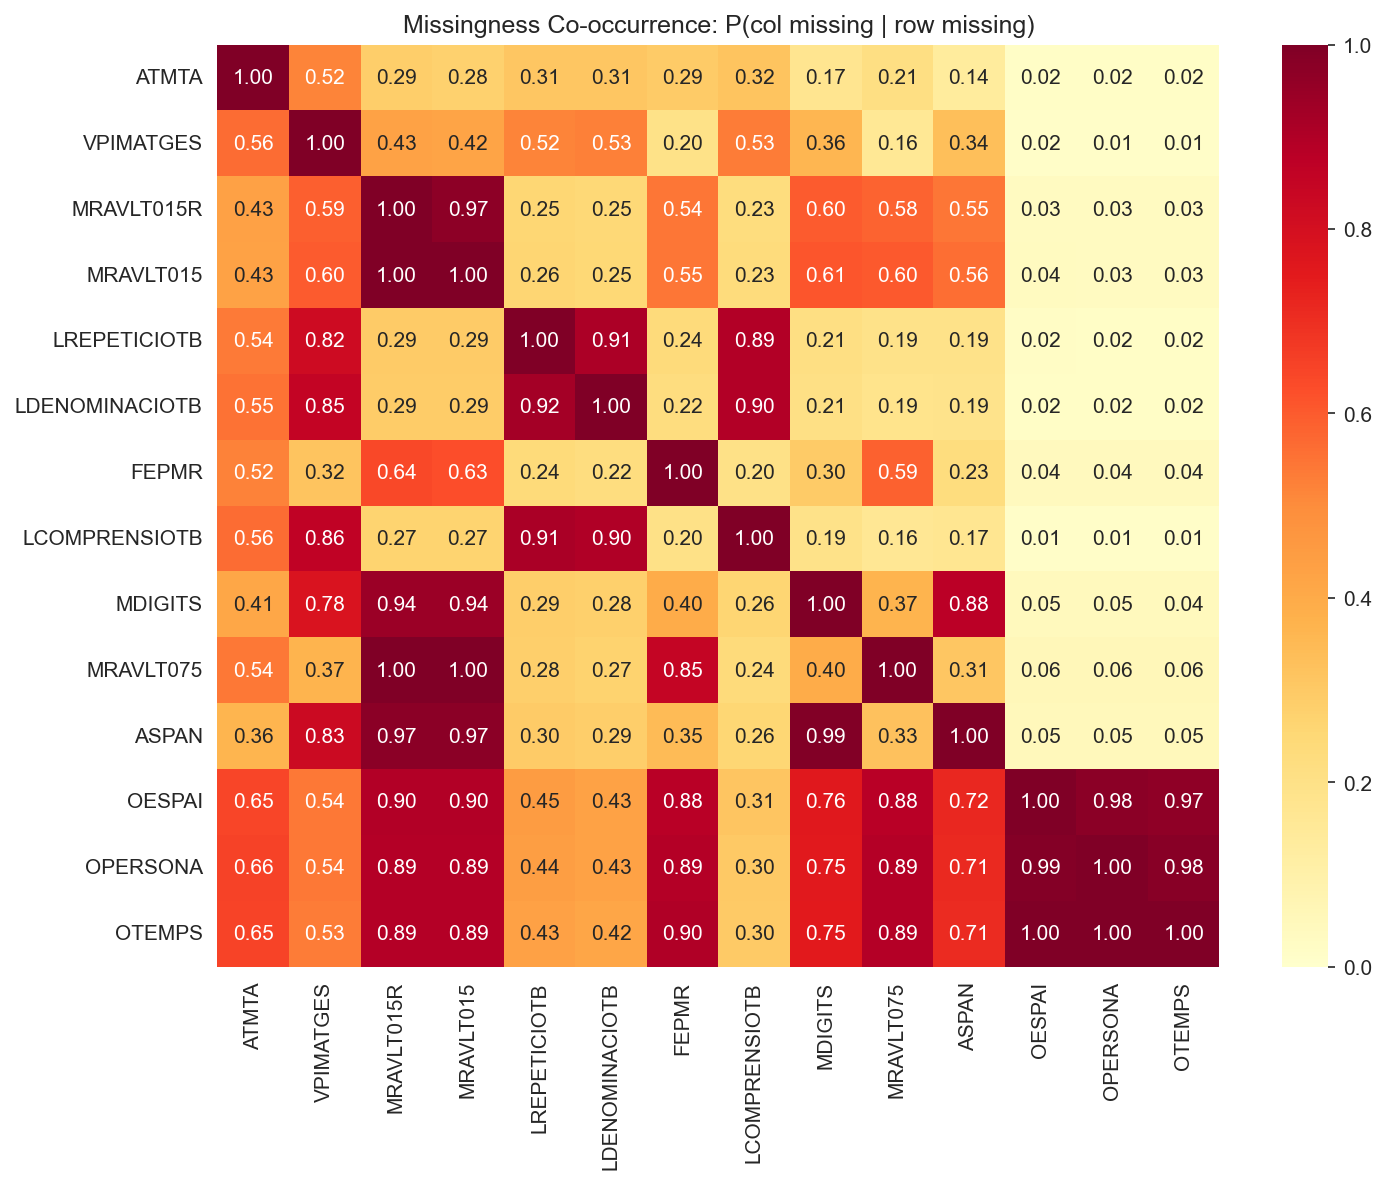

Co-occurrence matrix shape: (14, 14)
Saved: dl_missingness_cooccurrence.png


In [4]:
# Compute missingness co-occurrence matrix
# cooccurrence[j, k] = P(variable k is missing | variable j is missing)
n_vars = missing_mask.shape[1]
cooccurrence = np.zeros((n_vars, n_vars), dtype=np.float32)

for j in range(n_vars):
    j_missing = missing_mask[:, j]
    n_j = j_missing.sum()
    if n_j == 0:
        cooccurrence[j, :] = 0.0
        continue
    for k in range(n_vars):
        cooccurrence[j, k] = (j_missing & missing_mask[:, k]).sum() / n_j

# Visualise
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cooccurrence, xticklabels=ELIGIBLE_VARS, yticklabels=ELIGIBLE_VARS,
            annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('Missingness Co-occurrence: P(col missing | row missing)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'dl_missingness_cooccurrence.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Co-occurrence matrix shape: {cooccurrence.shape}')
print('Saved: dl_missingness_cooccurrence.png')


def pattern_aware_corruption(X_batch, obs_mask_batch, cooccurrence_matrix,
                              corruption_rate=0.2, pattern_frac=0.5):
    """Generate corruption masks that mimic real missingness patterns.
    
    For pattern_frac of samples: pick a seed variable, corrupt correlated vars
    based on co-occurrence probabilities. For the rest: uniform random corruption.
    Total expected corruption rate ~ corruption_rate.
    """
    batch_size, n_vars = X_batch.shape
    corruption_mask = torch.ones_like(X_batch)  # 1 = keep, 0 = corrupt
    
    n_pattern = int(batch_size * pattern_frac)
    cooc_tensor = torch.tensor(cooccurrence_matrix, dtype=torch.float32)
    
    for i in range(batch_size):
        obs_indices = torch.where(obs_mask_batch[i] > 0.5)[0]
        if len(obs_indices) == 0:
            continue
            
        if i < n_pattern and len(obs_indices) > 1:
            # Pattern-aware: pick a seed variable, corrupt correlated vars
            seed_idx = obs_indices[torch.randint(len(obs_indices), (1,))].item()
            probs = cooc_tensor[seed_idx, :].clone()
            # Scale probabilities so expected corruption ~ corruption_rate
            probs = probs * (corruption_rate / (probs.mean() + 1e-8))
            probs = probs.clamp(0, 0.8)  # cap individual corruption probability
            # Only corrupt observed positions
            corrupt_draw = torch.rand(n_vars) < probs
            corrupt_draw = corrupt_draw & (obs_mask_batch[i] > 0.5)
            corruption_mask[i][corrupt_draw] = 0.0
        else:
            # Uniform random corruption on observed positions
            corrupt_draw = torch.rand(n_vars) < corruption_rate
            corrupt_draw = corrupt_draw & (obs_mask_batch[i] > 0.5)
            corruption_mask[i][corrupt_draw] = 0.0
    
    return corruption_mask

## Denoising Autoencoder (DAE) with Pattern-Aware Corruption

Architecture: 15 → 128 (ReLU, BN, Dropout 0.5) → 64 (ReLU, BN, Dropout 0.3) → 32 (ReLU) → 64 → 128 → 15 (Linear)  
Training: Corrupt 20% of *observed* values using **missingness-pattern-aware** corruption masks, minimise MSE on observed entries only.  
Imputation: Average over 5 runs with different seeds (analogous to MICE m=5 pooling).

In [5]:
class DenoisingAutoencoder(nn.Module):
    """Denoising Autoencoder for missing data imputation.
    
    Reference: Gondara & Wang (2018), MIDA: Multiple Imputation using
    Denoising Autoencoders.
    """
    def __init__(self, input_dim=15):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [6]:
def train_dae(X_std, obs_mask, cooccurrence_matrix=None, corruption_rate=0.2,
              epochs=200, batch_size=256, lr=1e-3, patience=20, seed=42):
    """Train a DAE with pattern-aware corruption and return the reconstructed matrix.
    
    Args:
        X_std: Standardised data matrix (n, p) with mean-filled missing values.
        obs_mask: Binary mask (n, p), 1 = observed, 0 = missing.
        cooccurrence_matrix: (p, p) conditional missingness probabilities. If None, uses uniform corruption.
        corruption_rate: Target fraction of observed values to corrupt.
        epochs: Maximum training epochs.
        batch_size: Mini-batch size.
        lr: Learning rate for Adam optimiser.
        patience: Early stopping patience.
        seed: Random seed.
    
    Returns:
        Reconstructed matrix (n, p) as numpy array, training losses list.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    n, p = X_std.shape
    X_tensor = torch.tensor(X_std, dtype=torch.float32)
    mask_tensor = torch.tensor(obs_mask, dtype=torch.float32)
    
    dataset = TensorDataset(X_tensor, mask_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model = DenoisingAutoencoder(input_dim=p).to(device)
    optimiser = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='min', factor=0.5, patience=10
    )
    
    best_loss = float('inf')
    patience_counter = 0
    losses = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        for X_batch, mask_batch in loader:
            X_batch = X_batch.to(device)
            mask_batch = mask_batch.to(device)
            
            # Pattern-aware or uniform corruption
            if cooccurrence_matrix is not None:
                corruption_mask = pattern_aware_corruption(
                    X_batch, mask_batch, cooccurrence_matrix,
                    corruption_rate=corruption_rate, pattern_frac=0.5
                ).to(device)
                X_corrupted = X_batch * corruption_mask
            else:
                corruption = (torch.rand_like(X_batch) > corruption_rate).float()
                X_corrupted = X_batch * corruption
            
            # Forward pass
            X_recon = model(X_corrupted)
            
            # MSE loss on observed entries only
            loss = ((X_recon - X_batch) ** 2 * mask_batch).sum() / mask_batch.sum()
            
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        scheduler.step(avg_loss)
        
        # Early stopping
        if avg_loss < best_loss - 1e-6:
            best_loss = avg_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'    Early stopping at epoch {epoch+1}')
                break
    
    # Load best model and reconstruct
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        X_recon = model(X_tensor.to(device)).cpu().numpy()
    
    return X_recon, losses

In [7]:
# DAE: 5 runs with different seeds, average (like MICE m=5 pooling)
# Uses pattern-aware corruption based on empirical missingness co-occurrence
print('=== DAE Imputation (5 runs, pattern-aware corruption) ===')
n_runs = 5
dae_reconstructions = []
dae_all_losses = []

for run in range(n_runs):
    seed = RANDOM_STATE + run
    print(f'  Run {run+1}/{n_runs} (seed={seed})...')
    recon, losses = train_dae(
        X_standardised, observed_mask,
        cooccurrence_matrix=cooccurrence,
        corruption_rate=0.2, epochs=200, batch_size=256,
        lr=1e-3, patience=20, seed=seed
    )
    dae_reconstructions.append(recon)
    dae_all_losses.append(losses)
    print(f'    Final loss: {losses[-1]:.6f}, epochs: {len(losses)}')

# Average reconstructions across runs
dae_recon_avg = np.mean(dae_reconstructions, axis=0)

# De-standardise
dae_imputed = dae_recon_avg * col_stds + col_means

# Only replace missing values (keep original observed values)
X_dae = X.values.copy()
X_dae[missing_mask] = dae_imputed[missing_mask]

X_dae_df = pd.DataFrame(X_dae, columns=ELIGIBLE_VARS, index=X.index)
X_dae_df.to_csv(os.path.join(IMPUTED_DIR, 'Imputed_DAE.csv'))
print(f'\nDAE Shape: {X_dae_df.shape}, Missing remaining: {X_dae_df.isnull().sum().sum()}')
print('Saved: Imputed_DAE.csv')

=== DAE Imputation (5 runs, pattern-aware corruption) ===
  Run 1/5 (seed=42)...


    Early stopping at epoch 134
    Final loss: 0.218688, epochs: 134
  Run 2/5 (seed=43)...


    Early stopping at epoch 119
    Final loss: 0.220156, epochs: 119
  Run 3/5 (seed=44)...


    Early stopping at epoch 127
    Final loss: 0.222714, epochs: 127
  Run 4/5 (seed=45)...


    Early stopping at epoch 141
    Final loss: 0.216382, epochs: 141
  Run 5/5 (seed=46)...


    Early stopping at epoch 92
    Final loss: 0.221720, epochs: 92

DAE Shape: (17406, 14), Missing remaining: 0
Saved: Imputed_DAE.csv


## Variational Autoencoder (VAE) with Cyclical β-Annealing

Same layer dimensions as DAE; encoder outputs μ and log(σ²) for a 32-dim latent space.  
Loss: MSE on observed entries + β · KL divergence.  
**Cyclical β-annealing**: β ramps linearly from 0 to β_max (0.1) over each 40-epoch cycle, avoiding posterior collapse (Fu et al., 2019).  
Imputation: K=20 latent samples, decode each, average predictions.

In [8]:
class VariationalAutoencoder(nn.Module):
    """Variational Autoencoder for missing data imputation.
    
    References:
      - Kingma & Welling (2014), Auto-Encoding Variational Bayes.
      - McCoy et al. (2018), Variational Autoencoders for Missing Data Imputation.
    """
    def __init__(self, input_dim=15, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder_body = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
        )
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
        )
    
    def encode(self, x):
        h = self.encoder_body(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        return self.decode(z), mu, logvar

In [9]:
def vae_loss(x_recon, x, mu, logvar, obs_mask, beta=0.1):
    """VAE loss: MSE on observed + beta * KL divergence."""
    mse = ((x_recon - x) ** 2 * obs_mask).sum() / obs_mask.sum()
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return mse + beta * kl, mse.item(), kl.item()


def cyclical_beta(epoch, cycle_length=40, beta_max=0.1, proportion=0.5):
    """Cyclical beta annealing schedule (Fu et al., 2019).
    
    Within each cycle: beta ramps linearly from 0 to beta_max over the first
    `proportion` of the cycle, then holds at beta_max for the remainder.
    """
    cycle_pos = epoch % cycle_length
    ramp_end = int(cycle_length * proportion)
    if ramp_end == 0:
        return beta_max
    return min(cycle_pos / ramp_end, 1.0) * beta_max


def train_vae(X_std, obs_mask, beta_max=0.1, beta_schedule='cyclical',
              cycle_length=40, epochs=200, batch_size=256, lr=1e-3,
              patience=20, seed=42):
    """Train a VAE with cyclical beta-annealing and return multi-sample imputation.
    
    Args:
        X_std: Standardised data matrix (n, p).
        obs_mask: Binary mask (n, p), 1 = observed.
        beta_max: Maximum weight on KL divergence term.
        beta_schedule: 'cyclical' for cyclical annealing, 'fixed' for constant beta.
        cycle_length: Number of epochs per annealing cycle.
        epochs: Maximum training epochs.
        batch_size: Mini-batch size.
        lr: Learning rate.
        patience: Early stopping patience.
        seed: Random seed.
    
    Returns:
        Multi-sample reconstruction (n, p), training losses list, beta history list.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    n, p = X_std.shape
    X_tensor = torch.tensor(X_std, dtype=torch.float32)
    mask_tensor = torch.tensor(obs_mask, dtype=torch.float32)
    
    dataset = TensorDataset(X_tensor, mask_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model = VariationalAutoencoder(input_dim=p, latent_dim=32).to(device)
    optimiser = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='min', factor=0.5, patience=10
    )
    
    best_loss = float('inf')
    patience_counter = 0
    losses = []
    mse_history = []
    kl_history = []
    beta_history = []
    
    for epoch in range(epochs):
        # Compute beta for this epoch
        if beta_schedule == 'cyclical':
            beta_t = cyclical_beta(epoch, cycle_length=cycle_length, beta_max=beta_max)
        else:
            beta_t = beta_max
        beta_history.append(beta_t)
        
        model.train()
        epoch_loss = 0.0
        epoch_mse = 0.0
        epoch_kl = 0.0
        n_batches = 0
        
        for X_batch, mask_batch in loader:
            X_batch = X_batch.to(device)
            mask_batch = mask_batch.to(device)
            
            X_recon, mu, logvar = model(X_batch)
            loss, mse_val, kl_val = vae_loss(X_recon, X_batch, mu, logvar, mask_batch, beta_t)
            
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            
            epoch_loss += loss.item()
            epoch_mse += mse_val
            epoch_kl += kl_val
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        mse_history.append(epoch_mse / n_batches)
        kl_history.append(epoch_kl / n_batches)
        scheduler.step(avg_loss)
        
        if avg_loss < best_loss - 1e-6:
            best_loss = avg_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'    Early stopping at epoch {epoch+1}')
                break
    
    # Load best model, generate K=20 latent samples, average
    model.load_state_dict(best_state)
    model.eval()
    K = 20
    reconstructions = []
    with torch.no_grad():
        X_input = X_tensor.to(device)
        mu, logvar = model.encode(X_input)
        for _ in range(K):
            z = model.reparameterise(mu, logvar)
            x_recon = model.decode(z).cpu().numpy()
            reconstructions.append(x_recon)
    
    return np.mean(reconstructions, axis=0), losses, beta_history, mse_history, kl_history

In [10]:
# VAE training with cyclical beta-annealing and multi-sample imputation
print('=== VAE Imputation (cyclical β-annealing) ===')
vae_recon, vae_losses, vae_beta_hist, vae_mse_hist, vae_kl_hist = train_vae(
    X_standardised, observed_mask,
    beta_max=0.1, beta_schedule='cyclical', cycle_length=40,
    epochs=200, batch_size=256,
    lr=1e-3, patience=20, seed=RANDOM_STATE
)
print(f'Final loss: {vae_losses[-1]:.6f}, epochs: {len(vae_losses)}')

# De-standardise
vae_imputed = vae_recon * col_stds + col_means

# Only replace missing values
X_vae = X.values.copy()
X_vae[missing_mask] = vae_imputed[missing_mask]

X_vae_df = pd.DataFrame(X_vae, columns=ELIGIBLE_VARS, index=X.index)
X_vae_df.to_csv(os.path.join(IMPUTED_DIR, 'Imputed_VAE.csv'))
print(f'\nVAE Shape: {X_vae_df.shape}, Missing remaining: {X_vae_df.isnull().sum().sum()}')
print('Saved: Imputed_VAE.csv')

=== VAE Imputation (cyclical β-annealing) ===


    Early stopping at epoch 62
Final loss: 0.172360, epochs: 62

VAE Shape: (17406, 14), Missing remaining: 0
Saved: Imputed_VAE.csv


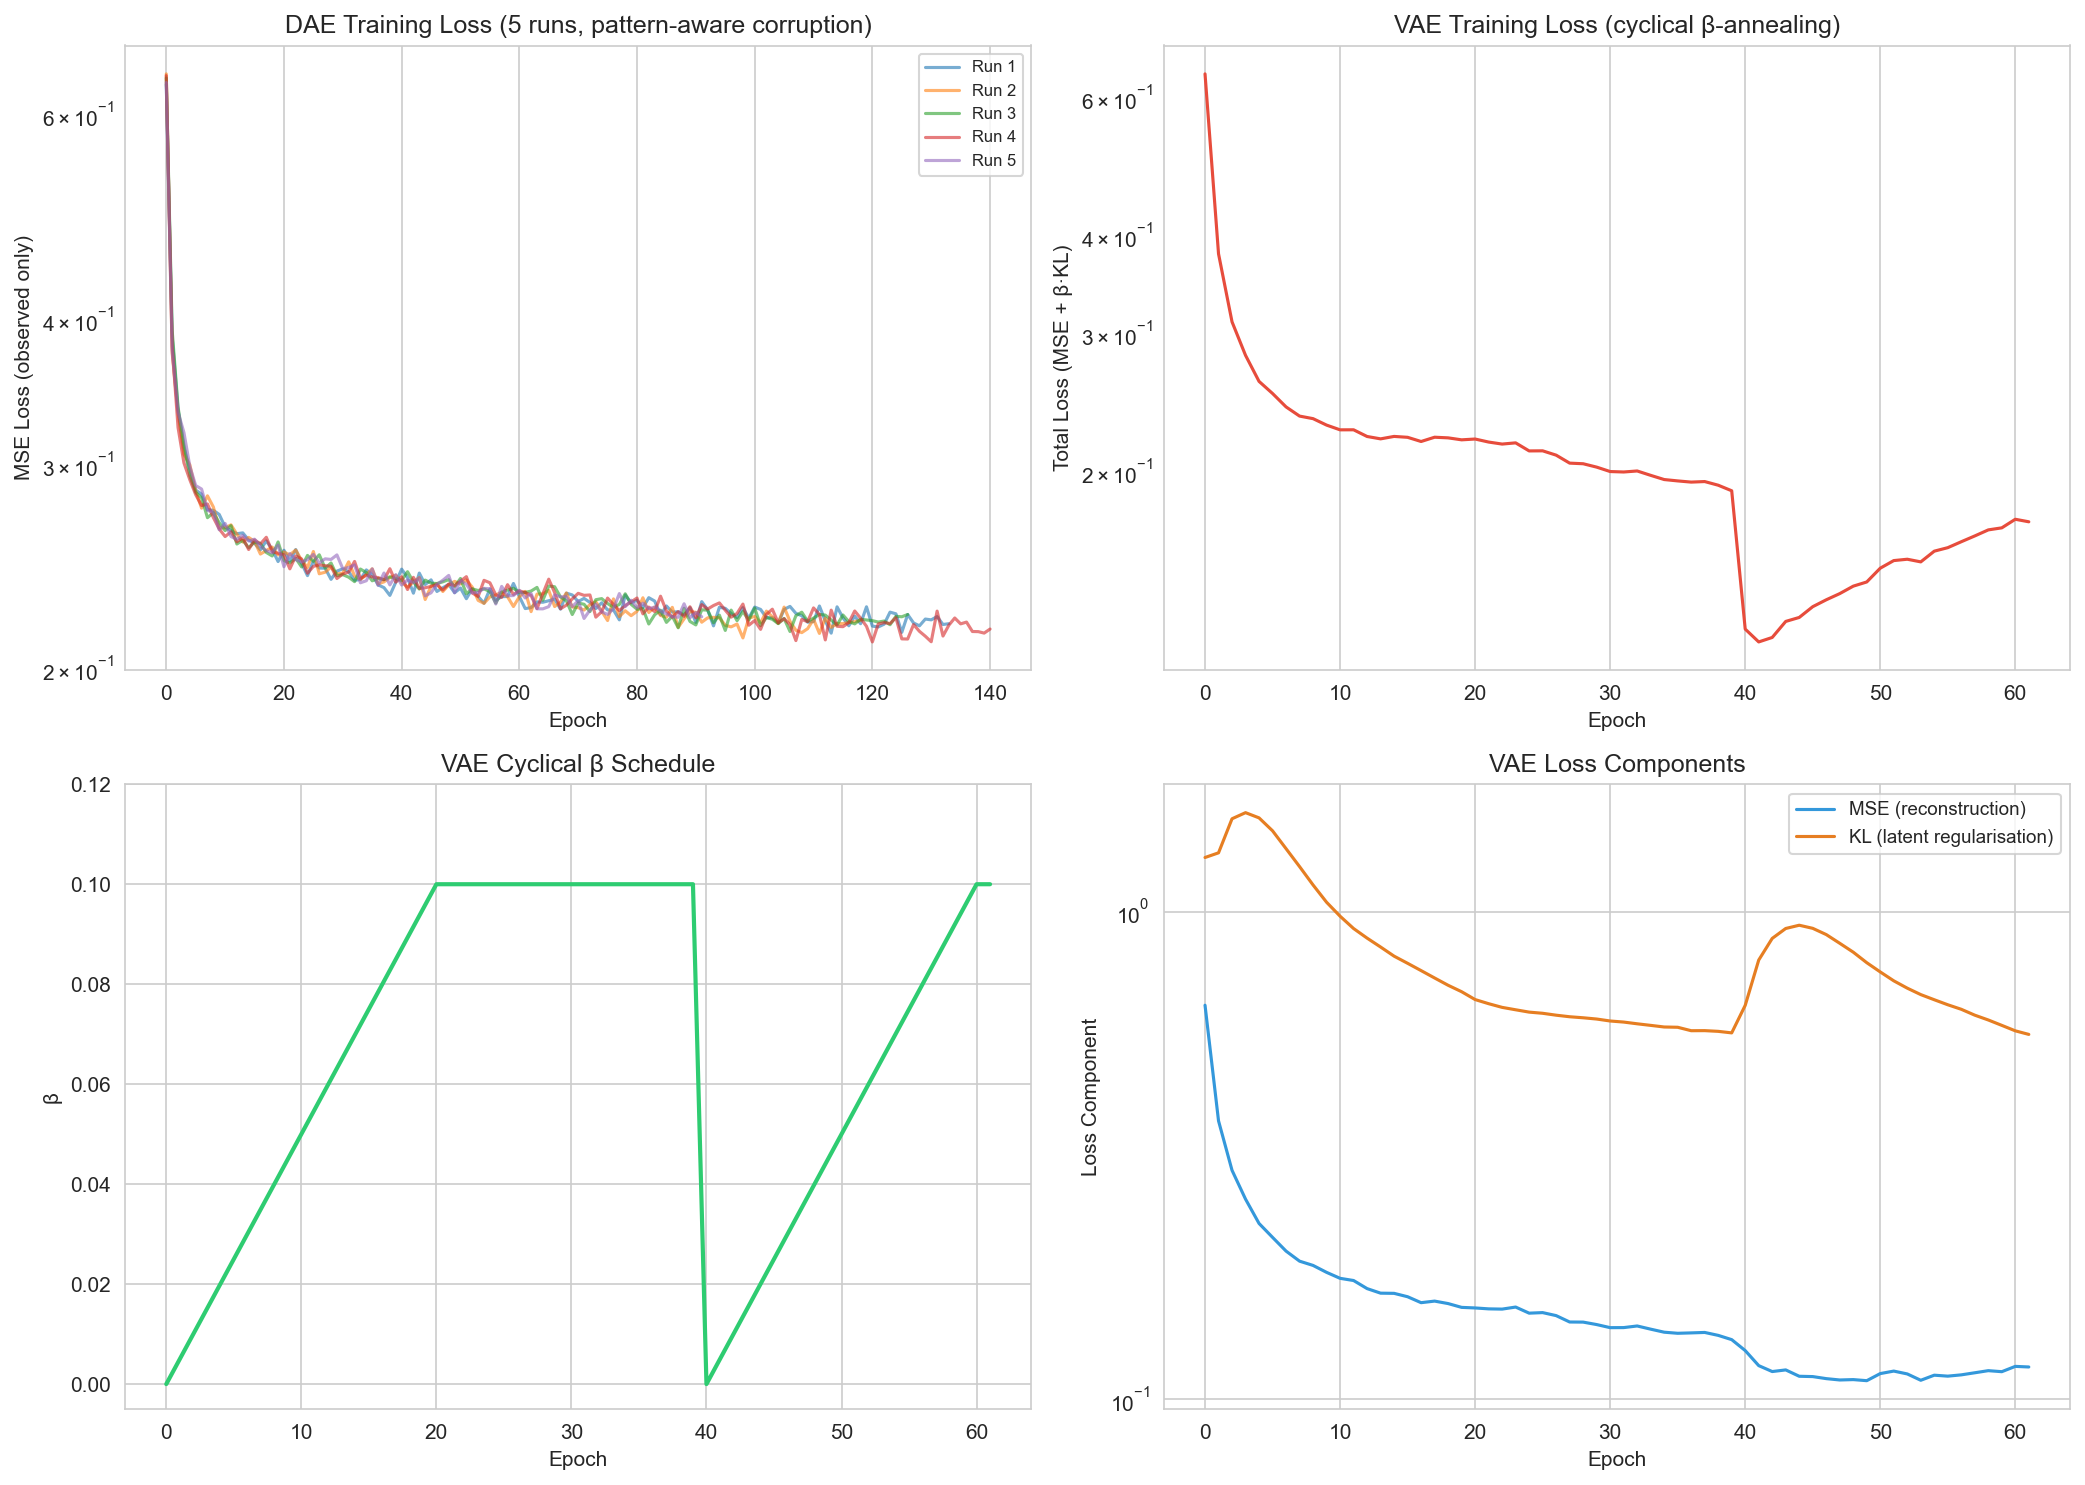

Saved: dl_imputation_training_curves.png


In [11]:
# Training loss curves with VAE beta schedule and component breakdown
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# DAE loss curves (5 runs)
ax1 = axes[0, 0]
for i, losses in enumerate(dae_all_losses):
    ax1.plot(losses, alpha=0.6, label=f'Run {i+1}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss (observed only)')
ax1.set_title('DAE Training Loss (5 runs, pattern-aware corruption)')
ax1.legend(fontsize=8)
ax1.set_yscale('log')

# VAE total loss curve
ax2 = axes[0, 1]
ax2.plot(vae_losses, color='#e74c3c')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Total Loss (MSE + β·KL)')
ax2.set_title('VAE Training Loss (cyclical β-annealing)')
ax2.set_yscale('log')

# VAE beta schedule
ax3 = axes[1, 0]
ax3.plot(vae_beta_hist, color='#2ecc71', linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('β')
ax3.set_title('VAE Cyclical β Schedule')
ax3.set_ylim(-0.005, max(vae_beta_hist) * 1.2)

# VAE MSE and KL components
ax4 = axes[1, 1]
ax4.plot(vae_mse_hist, label='MSE (reconstruction)', color='#3498db')
ax4.plot(vae_kl_hist, label='KL (latent regularisation)', color='#e67e22')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Loss Component')
ax4.set_title('VAE Loss Components')
ax4.legend(fontsize=9)
ax4.set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'dl_imputation_training_curves.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: dl_imputation_training_curves.png')

## Held-Out RMSE Evaluation

Hold out 10% of observed values, impute them, and measure reconstruction quality directly. This provides a quantitative imputation quality metric independent of downstream clustering.

=== Held-Out RMSE Evaluation ===
Evaluating DAE (3 folds, 10% holdout)...


    Early stopping at epoch 93


    Early stopping at epoch 98


    Early stopping at epoch 89


    Early stopping at epoch 70


    Early stopping at epoch 62
  DAE — RMSE: 13.4406, MAE: 3.5459
Evaluating VAE (3 folds, 10% holdout)...


    Early stopping at epoch 57


    Early stopping at epoch 57


    Early stopping at epoch 57
  VAE — RMSE: 14.4840, MAE: 3.8981

=== Per-Variable RMSE ===
      Variable  DAE_RMSE  VAE_RMSE
         ATMTA   53.3332   57.0008
     VPIMATGES    2.4787    2.6074
    MRAVLT015R    3.1972    3.8047
     MRAVLT015    2.0731    2.2847
  LREPETICIOTB    0.7150    0.8379
LDENOMINACIOTB    1.4592    1.7101
         FEPMR   11.1870   12.7525
 LCOMPRENSIOTB    1.9194    2.1797
       MDIGITS    0.8670    1.0049
     MRAVLT075    7.2568    8.4544
         ASPAN    1.0318    1.1461
        OESPAI    0.7280    0.8588
      OPERSONA    0.5409    0.6124
        OTEMPS    3.6227    4.4231

Saved: DL_HeldOut_RMSE.csv


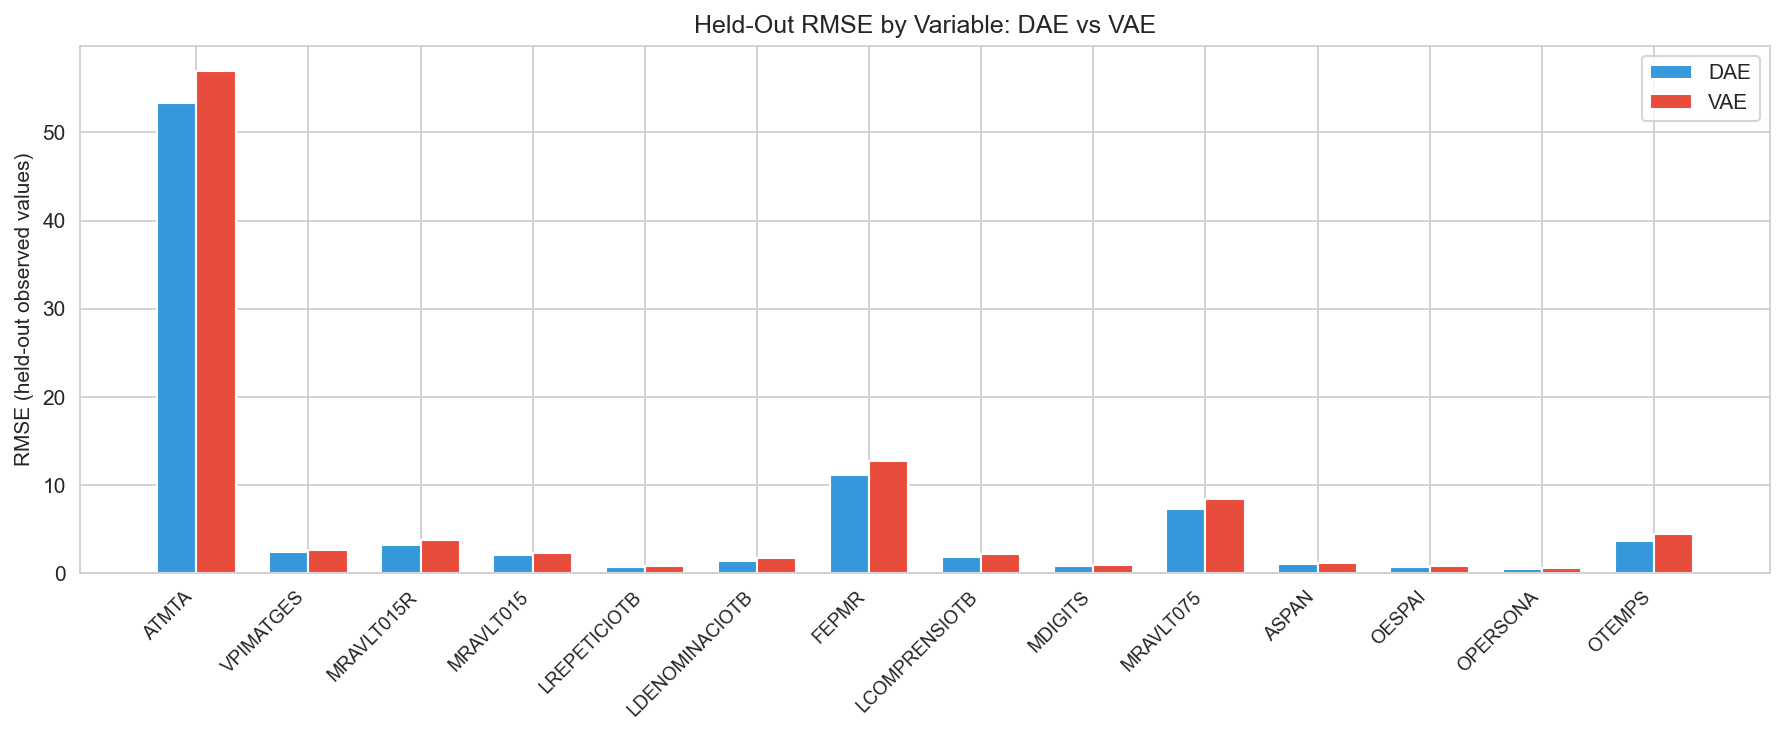

Saved: dl_held_out_rmse.png


In [12]:
def held_out_evaluation(X_raw, observed_mask, impute_fn, holdout_frac=0.10,
                        n_folds=5, seed=42):
    """Evaluate imputation quality by holding out observed values.
    
    Args:
        X_raw: Original data matrix with NaN for missing.
        observed_mask: Boolean mask, True where observed.
        impute_fn: Callable(X_with_extra_missing, obs_mask) -> imputed matrix.
        holdout_frac: Fraction of observed values to hold out.
        n_folds: Number of random holdout folds to average.
        seed: Random seed.
    
    Returns:
        Dict with per-variable and overall RMSE, MAE.
    """
    rng = np.random.RandomState(seed)
    n, p = X_raw.shape
    obs_indices = np.argwhere(observed_mask.astype(bool))  # (N_obs, 2)
    
    all_rmse = []
    all_mae = []
    per_var_rmse = {j: [] for j in range(p)}
    
    for fold in range(n_folds):
        # Randomly select holdout_frac of observed entries
        n_holdout = int(len(obs_indices) * holdout_frac)
        holdout_idx = rng.choice(len(obs_indices), size=n_holdout, replace=False)
        holdout_positions = obs_indices[holdout_idx]
        
        # Create modified masks
        modified_mask = observed_mask.copy()
        for r, c in holdout_positions:
            modified_mask[r, c] = 0.0
        
        # Create modified data (set holdout to NaN then mean-fill)
        X_modified = X_raw.copy()
        true_values = np.array([X_raw[r, c] for r, c in holdout_positions])
        for r, c in holdout_positions:
            X_modified[r, c] = np.nan
        
        # Impute
        imputed = impute_fn(X_modified, modified_mask)
        
        # Extract imputed values at holdout positions
        pred_values = np.array([imputed[r, c] for r, c in holdout_positions])
        
        # Compute metrics
        errors = pred_values - true_values
        fold_rmse = np.sqrt(np.mean(errors ** 2))
        fold_mae = np.mean(np.abs(errors))
        all_rmse.append(fold_rmse)
        all_mae.append(fold_mae)
        
        # Per-variable
        for r, c in holdout_positions:
            per_var_rmse[c].append((imputed[r, c] - X_raw[r, c]) ** 2)
    
    # Aggregate per-variable RMSE
    var_rmse = {}
    for j in range(p):
        if per_var_rmse[j]:
            var_rmse[j] = np.sqrt(np.mean(per_var_rmse[j]))
        else:
            var_rmse[j] = np.nan
    
    return {
        'overall_rmse': np.mean(all_rmse),
        'overall_mae': np.mean(all_mae),
        'per_variable_rmse': var_rmse,
    }


# Define imputation functions for DAE and VAE
def dae_impute_fn(X_modified, modified_mask):
    """DAE imputation on modified data."""
    cm = np.nanmean(X_modified, axis=0)
    cs = np.nanstd(X_modified, axis=0)
    cs[cs == 0] = 1.0
    X_f = X_modified.copy()
    for j in range(X_f.shape[1]):
        m = np.isnan(X_f[:, j])
        X_f[m, j] = cm[j]
    X_s = ((X_f - cm) / cs).astype(np.float32)
    recons = []
    for run in range(3):  # 3 runs for speed in evaluation
        r, _ = train_dae(X_s, modified_mask, cooccurrence_matrix=cooccurrence,
                         corruption_rate=0.2, epochs=100, batch_size=256,
                         lr=1e-3, patience=15, seed=RANDOM_STATE + run)
        recons.append(r)
    avg = np.mean(recons, axis=0)
    return avg * cs + cm

def vae_impute_fn(X_modified, modified_mask):
    """VAE imputation on modified data."""
    cm = np.nanmean(X_modified, axis=0)
    cs = np.nanstd(X_modified, axis=0)
    cs[cs == 0] = 1.0
    X_f = X_modified.copy()
    for j in range(X_f.shape[1]):
        m = np.isnan(X_f[:, j])
        X_f[m, j] = cm[j]
    X_s = ((X_f - cm) / cs).astype(np.float32)
    r, _, _, _, _ = train_vae(X_s, modified_mask, beta_max=0.1,
                               beta_schedule='cyclical', cycle_length=40,
                               epochs=100, batch_size=256, lr=1e-3,
                               patience=15, seed=RANDOM_STATE)
    return r * cs + cm


print('=== Held-Out RMSE Evaluation ===')
print('Evaluating DAE (3 folds, 10% holdout)...')
dae_eval = held_out_evaluation(X.values, observed_mask, dae_impute_fn,
                                holdout_frac=0.10, n_folds=3, seed=RANDOM_STATE)
print(f'  DAE — RMSE: {dae_eval["overall_rmse"]:.4f}, MAE: {dae_eval["overall_mae"]:.4f}')

print('Evaluating VAE (3 folds, 10% holdout)...')
vae_eval = held_out_evaluation(X.values, observed_mask, vae_impute_fn,
                                holdout_frac=0.10, n_folds=3, seed=RANDOM_STATE)
print(f'  VAE — RMSE: {vae_eval["overall_rmse"]:.4f}, MAE: {vae_eval["overall_mae"]:.4f}')

# Per-variable RMSE comparison
rmse_rows = []
for j, var in enumerate(ELIGIBLE_VARS):
    rmse_rows.append({
        'Variable': var,
        'DAE_RMSE': round(dae_eval['per_variable_rmse'][j], 4),
        'VAE_RMSE': round(vae_eval['per_variable_rmse'][j], 4),
    })
rmse_df = pd.DataFrame(rmse_rows)
rmse_df.to_csv(os.path.join(RESULTS_DIR, 'DL_HeldOut_RMSE.csv'), index=False)
print('\n=== Per-Variable RMSE ===')
print(rmse_df.to_string(index=False))
print('\nSaved: DL_HeldOut_RMSE.csv')

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(ELIGIBLE_VARS))
w = 0.35
ax.bar(x - w/2, rmse_df['DAE_RMSE'], w, label='DAE', color='#3498db')
ax.bar(x + w/2, rmse_df['VAE_RMSE'], w, label='VAE', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(ELIGIBLE_VARS, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('RMSE (held-out observed values)')
ax.set_title('Held-Out RMSE by Variable: DAE vs VAE')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'dl_held_out_rmse.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: dl_held_out_rmse.png')

In [13]:
# Summary statistics across all 10 methods
ALL_METHODS = ['Mean', 'KNN', 'MICE', 'MissForest', 'PMM', 'EM', 'SoftImpute', 'NMF', 'DAE', 'VAE']
summary_rows = []

for method in ALL_METHODS:
    fpath = os.path.join(IMPUTED_DIR, f'Imputed_{method}.csv')
    if os.path.exists(fpath):
        df_m = pd.read_csv(fpath, index_col=0)
        summary_rows.append({
            'Method': method,
            'Missing Remaining': df_m.isnull().sum().sum(),
            'Mean (all vars)': round(df_m.mean().mean(), 4),
            'Std (all vars)': round(df_m.std().mean(), 4),
            'Min': round(df_m.min().min(), 4),
            'Max': round(df_m.max().max(), 4)
        })

summary_df = pd.DataFrame(summary_rows)
print('=== All 10 Imputation Methods Summary ===')
print(summary_df.to_string(index=False))

=== All 10 Imputation Methods Summary ===
    Method  Missing Remaining  Mean (all vars)  Std (all vars)      Min   Max
      Mean                  0          18.2472          7.1396   0.0000 999.0
       KNN                  0          18.7678          8.3141   0.0000 999.0
      MICE                  0          18.9396          8.6633 -52.6546 999.0
MissForest                  0          19.4997          9.6501   0.0000 999.0
       PMM                  0          18.9081          9.5999   0.0000 999.0
        EM                  0          19.0690          9.1167 -56.6397 999.0
SoftImpute                  0          18.2404          7.4800 -36.5709 999.0
       NMF                  0          17.5941          7.5551   0.0000 999.0
       DAE                  0          18.3953          7.4705  -1.6471 999.0
       VAE                  0          18.1482          7.2645   0.0000 999.0


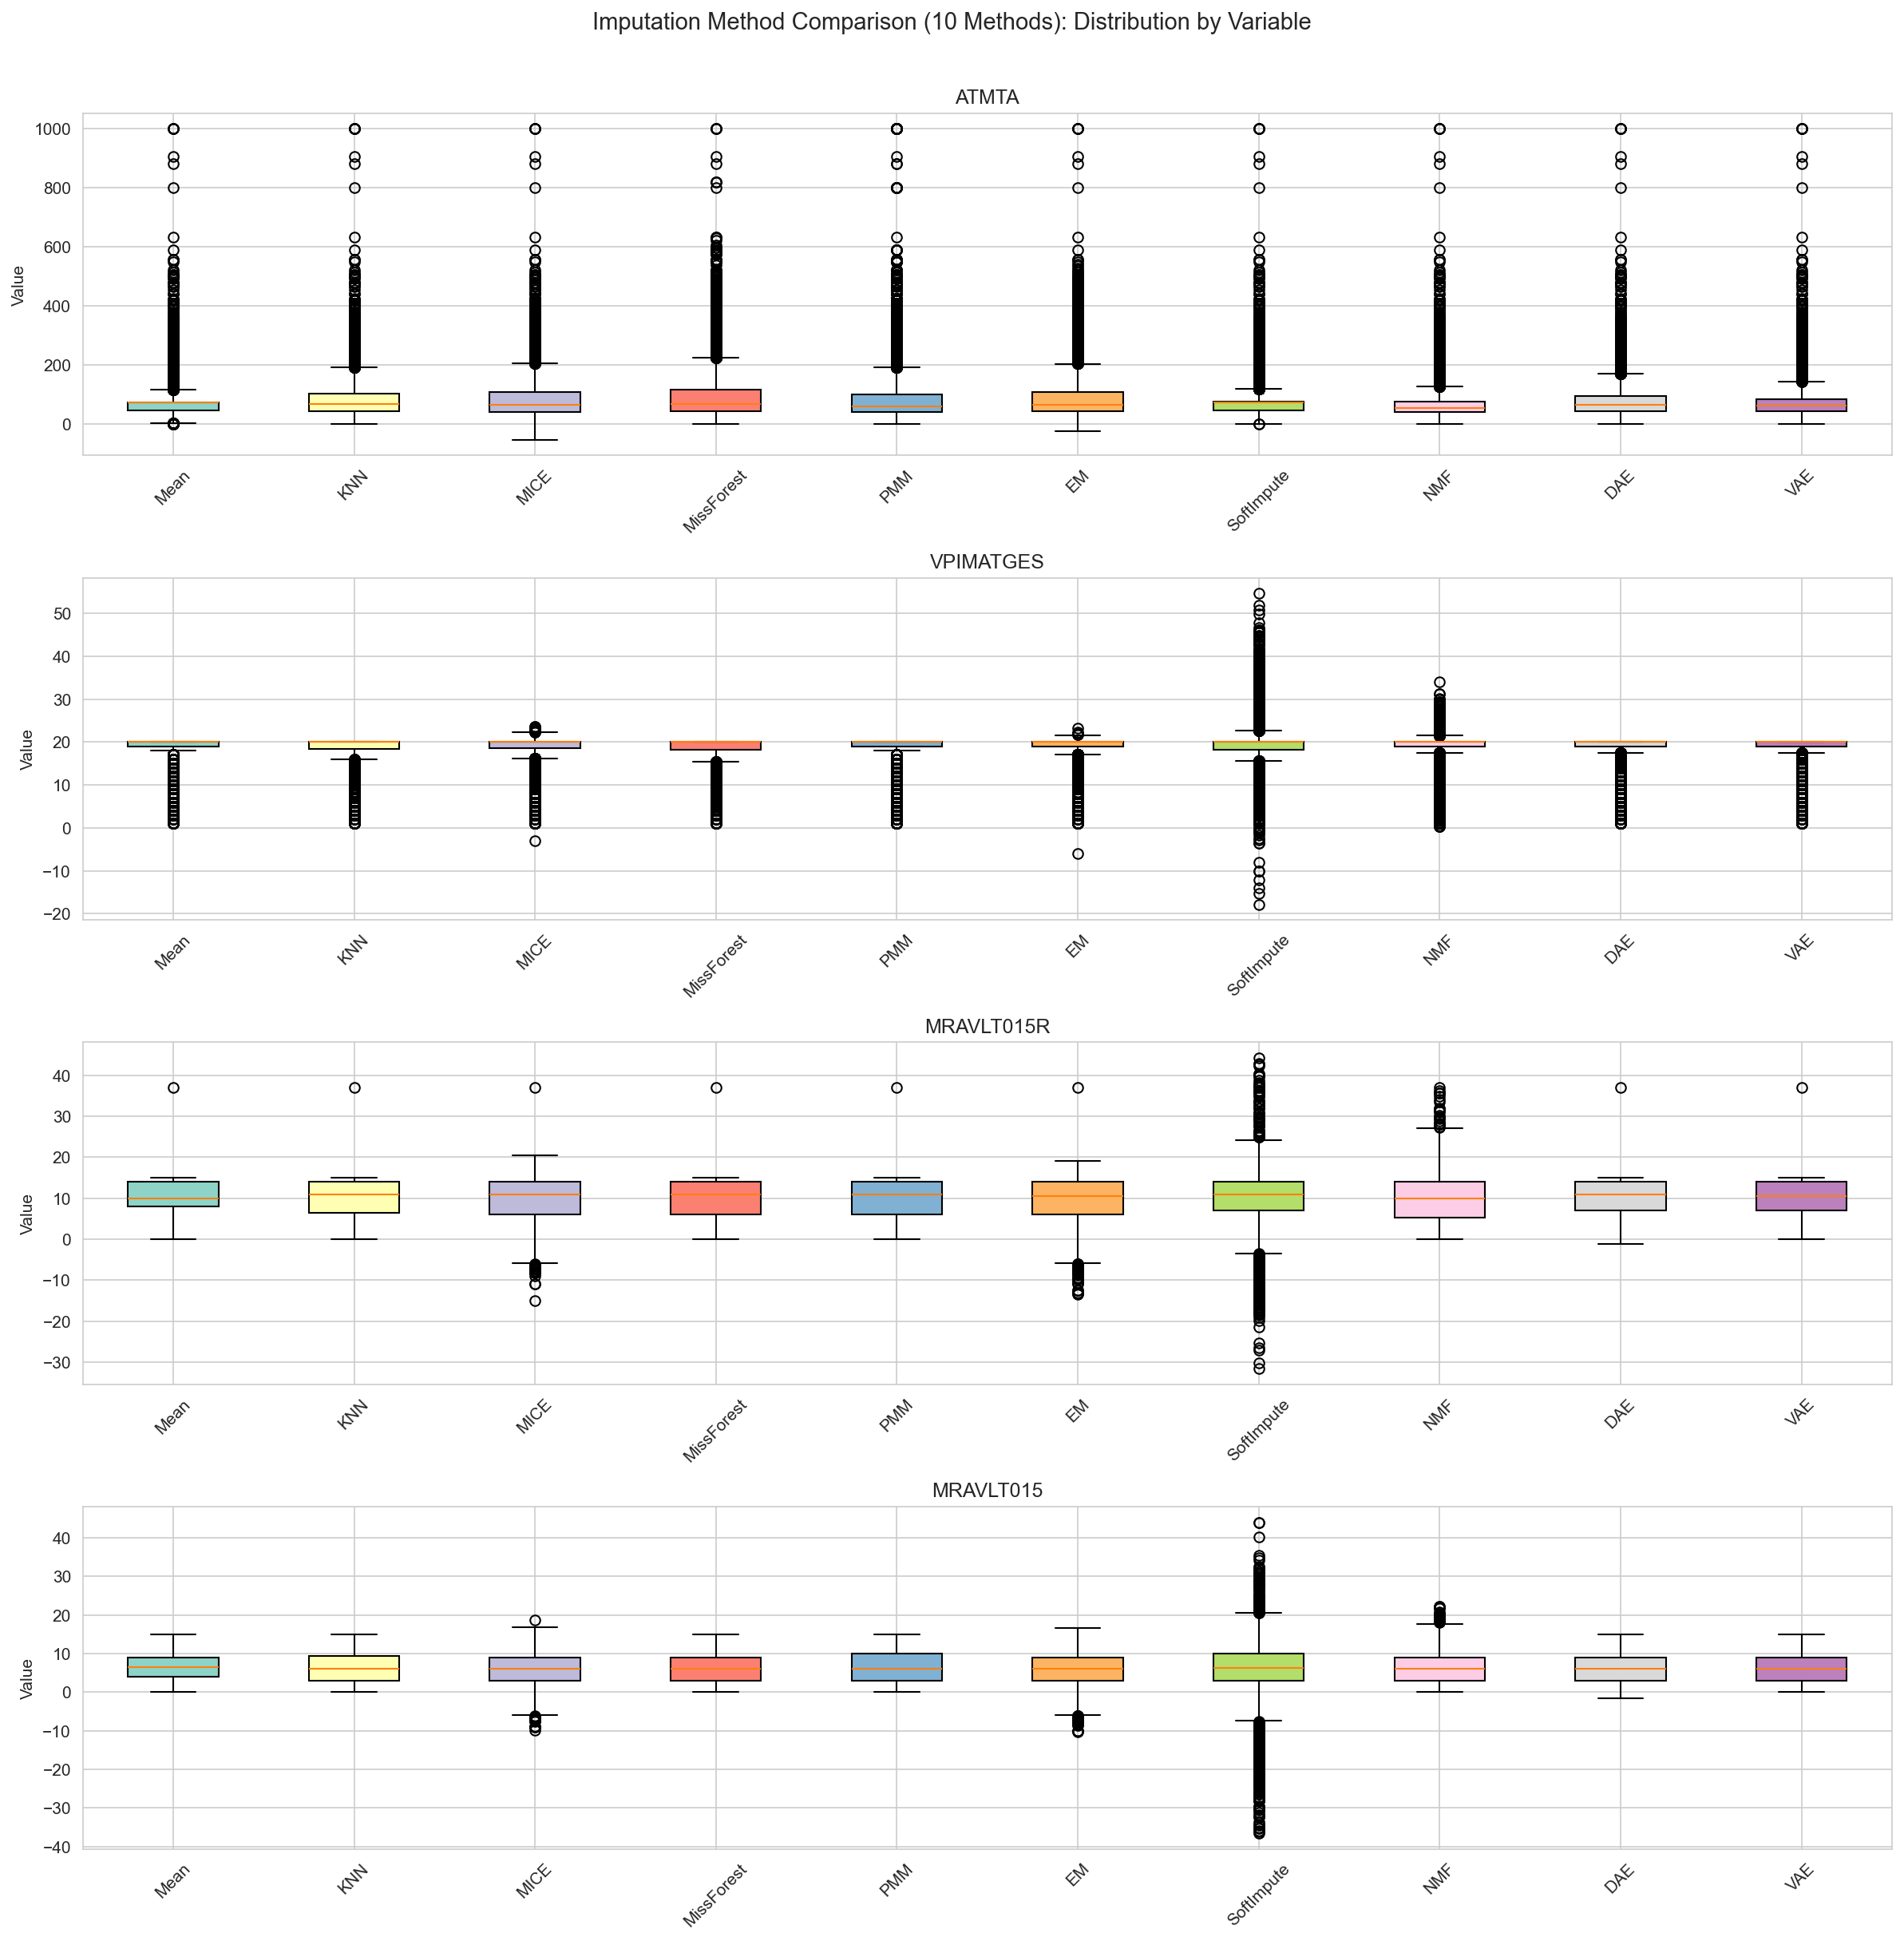

Saved: dl_imputation_comparison.png


In [14]:
# Distribution comparison boxplots — all 10 methods for first 4 variables
selected_vars = ELIGIBLE_VARS[:4]

fig, axes = plt.subplots(len(selected_vars), 1, figsize=(16, 4 * len(selected_vars)))

for idx, var in enumerate(selected_vars):
    ax = axes[idx]
    box_data = []
    available_methods = []
    for method in ALL_METHODS:
        fpath = os.path.join(IMPUTED_DIR, f'Imputed_{method}.csv')
        if os.path.exists(fpath):
            df_m = pd.read_csv(fpath, index_col=0)
            box_data.append(df_m[var].values)
            available_methods.append(method)
    
    bp = ax.boxplot(box_data, labels=available_methods, patch_artist=True)
    colors = sns.color_palette('Set3', len(available_methods))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f'{var}', fontsize=12)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'Imputation Method Comparison ({len(available_methods)} Methods): Distribution by Variable',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'dl_imputation_comparison.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: dl_imputation_comparison.png')

In [15]:
# Save summary CSV
summary_df.to_csv(os.path.join(RESULTS_DIR, 'DL_Imputation_Summary.csv'), index=False)
print('Saved: DL_Imputation_Summary.csv')
print(f'\n=== Notebook 1b Complete ===')
print(f'DAE: {os.path.join(IMPUTED_DIR, "Imputed_DAE.csv")}')
print(f'VAE: {os.path.join(IMPUTED_DIR, "Imputed_VAE.csv")}')

Saved: DL_Imputation_Summary.csv

=== Notebook 1b Complete ===
DAE: ../data/imputed_csv/Imputed_DAE.csv
VAE: ../data/imputed_csv/Imputed_VAE.csv
